# [최종 제출용] AI 생성 블로그 스팸 탐지 모델 통합 파이프라인

## 1. 프로젝트 핵심 목적
이 프로젝트의 핵심은 단순한 정확도 향상이 아닙니다. 핵심 연구 질문은 다음과 같습니다:
**"AI가 인간형 문체를 모방할수록 탐지 난이도는 어떻게 변화하는가?"**

따라서 본 파이프라인은 단순 Accuracy보다는 **탐지 난이도의 증가**, **SHAP 기반 Feature 변화**, **False Negative(미탐) 증가 현상**을 학술적으로 설명하는 데 집중합니다.

## 2. 실험 구조 요약
| Experiment | Human | AI_v1 | AI_v2 | 목적 |
|---|---|---|---|---|
| EXP1 | 600 | 600 | 0 | GPT형 AI 탐지 |
| EXP2 | 600 | 0 | 300 | 인간형 AI 탐지 |
| EXP3 | 600 | 300 | 300 | 혼합 AI 탐지 |
| AI_vs_AI | 0 | 300 | 300 | AI 위장술(문체 진화) 자체 분석 |

**EXP3는 실제 환경과 가장 유사한 실험입니다.**
실제 인터넷 생태계에서는 전형적인 GPT형 AI와 인간형으로 교묘하게 위장한 AI가 혼합되어 존재하기 때문입니다.

## 3. AI_v2 생성 이유
초기 EXP1에서는 Accuracy/F1이 지나치게 높게 나타났습니다.
분석 결과:
- `friendly_ending_count` (~해요, ~답니다)
- `adjective_ratio` (형용사 과다 사용)
- 특정 TF-IDF 감성 표현
등이 매우 강하게 작동하였습니다. 즉, 모델이 "AI 자체"보다 **"GPT스러운 친절한 블로그체"**만을 얕게 탐지하고 있을 가능성이 존재했습니다.

이를 보완하기 위해 아래와 같은 특성을 반영한 **AI_v2**를 생성했습니다:
* 건조체 및 정보형 문체
* 감정이 적은 서술
* 인간 특유의 불완전성 및 문장 길이 다양성 주입

## 4. 길이 편향 (Length Leakage) 방어 전략
현재 코드에서는 `char_count`, `raw_length`, `total_tokens` 등 직접적인 길이 피처를 모델 학습에서 완전히 배제하고 있습니다.
하지만 `sentence_count`, `avg_sentence_len`, `sentence_len_std` 등은 간접적으로 길이 구조를 반영할 수 있습니다.
따라서, 본 연구는 **"길이 편향을 완전히 제거했다"**가 아니라 **"길이 편향을 줄이기 위한 방어 실험을 수행하였다"**고 정의합니다.

## 5. Feature Mode 비교 실험
이 노트북은 모델이 단순 '단어'에 의존하는지, 보이지 않는 '문체 구조'에 의존하는지 파악하기 위해 3가지 모드를 지원합니다.
- `FEATURE_MODE = "tfidf_only"` : 단어 표현 중심 탐지
- `FEATURE_MODE = "meta_only"` : 형태소/문체 구조 중심 탐지
- `FEATURE_MODE = "combined"` : 표현 + 구조 혼합 탐지

In [1]:
import os
import sys
import site
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.sparse import hstack, csr_matrix

try:
    from konlpy.tag import Okt
except ImportError:
    !{sys.executable} -m pip install --upgrade --user konlpy
    from konlpy.tag import Okt
okt = Okt()

# ==========================================================================
# 실험 환경 전역 세팅
# ==========================================================================
EXPERIMENT_NAME = "exp3"   # "exp1", "exp2", "exp3", "ai_vs_ai"
FEATURE_MODE = "combined"  # "combined", "tfidf_only", "meta_only"

target_dir = "."
data_dir = os.path.join(target_dir, "dataset")
result_dir = os.path.join(target_dir, f"model_results_{EXPERIMENT_NAME}")
os.makedirs(result_dir, exist_ok=True)

if EXPERIMENT_NAME not in ["exp1", "exp2", "exp3", "ai_vs_ai"]:
    raise ValueError("[ERROR] EXPERIMENT_NAME 설정 오류")

print(f"\n==========================================================================")
print(f"현재 설정된 실험: {EXPERIMENT_NAME.upper()} | 모드: {FEATURE_MODE.upper()}")
print(f"==========================================================================")


현재 설정된 실험: EXP3 | 모드: COMBINED


In [2]:
# ==========================================================================
# 데이터 로드 및 전처리 (AI vs AI 포함)
# ==========================================================================
if EXPERIMENT_NAME == "exp1":
    input_file = os.path.join(data_dir, "ml_dataset_processed.csv") 
elif EXPERIMENT_NAME == "ai_vs_ai":
    input_file = os.path.join(data_dir, "ml_dataset_exp3_processed.csv")
else:
    input_file = os.path.join(data_dir, f"ml_dataset_{EXPERIMENT_NAME}_processed.csv")

if not os.path.exists(input_file):
    raise FileNotFoundError(f"[ERROR] 파일 없음: {input_file}")

df = pd.read_csv(input_file, encoding="utf-8-sig")

text_col = "content_clean" if "content_clean" in df.columns else "content_raw"
df[text_col] = df[text_col].fillna("").astype(str)
df = df[df[text_col].str.strip() != ""].reset_index(drop=True)

# 라벨 세팅 로직
if EXPERIMENT_NAME == "ai_vs_ai":
    df = df[df["is_ai"] == 1].reset_index(drop=True)
    y = (df["ai_type"] == "AI_v2").astype(int) # 0: AI_v1, 1: AI_v2
    print("[INFO] AI vs AI 모드 활성화: AI_v1(0) vs AI_v2(1)")
else:
    y = df["is_ai"].astype(int).copy()

print(f"[INFO] 전체 행 수: {len(df)}")
display(y.value_counts().rename("라벨 분포"))

[INFO] 전체 행 수: 1196


is_ai
1    600
0    596
Name: 라벨 분포, dtype: int64

In [3]:
# ==========================================================================
# 피처 세팅 및 분할 (random_state=42 통일)
# ==========================================================================
candidate_meta = ["char_count", "raw_length", "sentence_count", "avg_sentence_len", "sentence_len_std", "total_tokens", "noun_count", "verb_count", "adjective_count", "adverb_count", "josa_count", "noun_ratio", "verb_ratio", "adjective_ratio", "adverb_ratio", "josa_ratio", "noun_density", "josa_density", "friendly_ending_count", "llm_style_count", "period_count", "exclamation_count", "question_count", "tilde_count", "punctuation_ratio"]

# 길이 편향 방어: 직접 길이 카운트 배제
length_leakage = ["char_count", "raw_length", "total_tokens", "noun_count", "verb_count", "adjective_count", "adverb_count", "josa_count", "period_count", "exclamation_count", "question_count", "tilde_count"]
meta_features = [c for c in candidate_meta if c in df.columns and c not in length_leakage]

X_text = df[text_col].copy()
X_meta = df[meta_features].replace([np.inf, -np.inf], np.nan).fillna(0).copy()

X_train_t, X_temp_t, X_train_m, X_temp_m, y_train, y_temp = train_test_split(X_text, X_meta, y, test_size=0.3, random_state=42, stratify=y)
X_valid_t, X_test_t, X_valid_m, X_test_m, y_valid, y_test = train_test_split(X_temp_t, X_temp_m, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train_final, X_valid_final, X_test_final = None, None, None
feature_names = []

if FEATURE_MODE in ["combined", "tfidf_only"]:
    tfidf = TfidfVectorizer(max_features=300, ngram_range=(1, 2), min_df=2, max_df=0.90)
    X_tfidf_train = tfidf.fit_transform(X_train_t)
    X_tfidf_valid = tfidf.transform(X_valid_t)
    X_tfidf_test = tfidf.transform(X_test_t)
    tfidf_feature_names = [f"tfidf_{w}" for w in tfidf.get_feature_names_out()]

if FEATURE_MODE in ["combined", "meta_only"]:
    scaler = StandardScaler()
    X_meta_train_sp = csr_matrix(scaler.fit_transform(X_train_m))
    X_meta_valid_sp = csr_matrix(scaler.transform(X_valid_m))
    X_meta_test_sp = csr_matrix(scaler.transform(X_test_m))

if FEATURE_MODE == "combined":
    X_train_final = hstack([X_tfidf_train, X_meta_train_sp])
    X_valid_final = hstack([X_tfidf_valid, X_meta_valid_sp])
    X_test_final = hstack([X_tfidf_test, X_meta_test_sp])
    feature_names = tfidf_feature_names + meta_features
elif FEATURE_MODE == "tfidf_only":
    X_train_final, X_valid_final, X_test_final = X_tfidf_train, X_tfidf_valid, X_tfidf_test
    feature_names = tfidf_feature_names
elif FEATURE_MODE == "meta_only":
    X_train_final, X_valid_final, X_test_final = X_meta_train_sp, X_meta_valid_sp, X_meta_test_sp
    feature_names = meta_features


[평가 결과]
[VALID] Acc: 0.9944 | Pre: 1.0000 | Rec: 0.9889 | F1: 0.9944


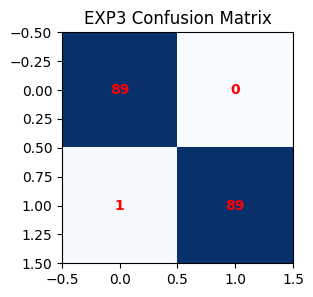

[TEST] Acc: 0.9833 | Pre: 0.9888 | Rec: 0.9778 | F1: 0.9832


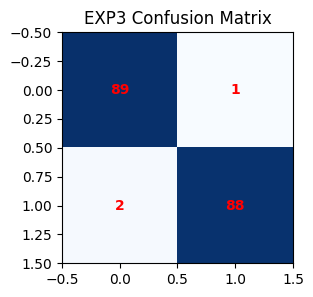

In [4]:
# ==========================================================================
# 모델 학습 및 성능 산출
# ==========================================================================
import xgboost as xgb
model = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric="logloss")
model.fit(X_train_final, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_final, y_train, cv=cv, scoring="f1")
cv_mean, cv_std = cv_scores.mean(), cv_scores.std()

def evaluate(X_data, y_true, X_text_original, X_meta_original, split_name):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]
    acc, pre, rec, f1 = accuracy_score(y_true, y_pred), precision_score(y_true, y_pred), recall_score(y_true, y_pred), f1_score(y_true, y_pred)
    
    print(f"[{split_name}] Acc: {acc:.4f} | Pre: {pre:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    
    # Save metric txt
    with open(os.path.join(result_dir, f"{split_name.lower()}_metrics.txt"), "w") as f:
        f.write(f"Acc: {acc}\nPre: {pre}\nRec: {rec}\nF1: {f1}\nCV_Mean: {cv_mean}\n")
        
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"{EXPERIMENT_NAME.upper()} Confusion Matrix")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="red", fontweight="bold")
    plt.savefig(os.path.join(result_dir, f"{split_name.lower()}_confusion_matrix.png"), bbox_inches='tight')
    plt.show()
    
    # DF 생성시 주요 meta feature 포함 (Error Analysis 용)
    res_df = pd.DataFrame({"content": X_text_original.reset_index(drop=True), "true_label": y_true.reset_index(drop=True), "pred_label": y_pred, "ai_probability": y_prob})
    meta_cols = ["sentence_len_std", "adjective_ratio", "friendly_ending_count", "verb_ratio"]
    for c in meta_cols:
        if c in X_meta_original.columns:
            res_df[c] = X_meta_original[c].reset_index(drop=True)
            
    return acc, pre, rec, f1, res_df

print("\n[평가 결과]")
valid_acc, valid_pre, valid_rec, valid_f1, valid_df = evaluate(X_valid_final, y_valid, X_valid_t, X_valid_m, "VALID")
test_acc, test_pre, test_rec, test_f1, test_df = evaluate(X_test_final, y_test, X_test_t, X_test_m, "TEST")

## 6. Error Analysis (오탐/미탐 원인 분석)
단순 출력이 아니라, 주요 문체 특성(`sentence_len_std`, `adjective_ratio` 등)을 함께 분석하여 "왜 모델이 속았는지" 해석합니다.

* **False Positive (오탐):** 인간인데 모델이 AI로 판단 (예: 너무 상투적인 감성 표현, 템플릿화된 문체)
* **False Negative (미탐):** AI인데 모델이 인간으로 판단 (예: 건조하고 짧은 문장 구조, 변칙적인 문체)


[False Positive 상위 사례] - 인간인데 AI로 판단된 광고성/기계적 글


,content,true_label,pred_label,ai_probability,sentence_len_std,adjective_ratio,friendly_ending_count,verb_ratio
93,가격대비 아주 훌륭하다! 비싸지만 아주 훌륭하다. 역시 정품케이스! 절대 빼지 않으...,0,1,0.819403,6.343501,0.129032,0,0.096774



[False Negative 상위 사례] - AI인데 인간으로 판단된 고도의 위장 글


,content,true_label,pred_label,ai_probability,sentence_len_std,adjective_ratio,friendly_ending_count,verb_ratio
125,아르노 아이폰은 처음엔 애매했는데 쓰다 보니 괜찮은 쪽으로 기울었다. 다만 설명이 ...,1,0,0.457727,5.953150,0.058824,0,0.137255
21,막국수 쪽은 사람이 꽤 많았다. 메뉴판 보고 고르는데 가격대는 평범했고 음식은 간이...,1,0,0.486146,4.582576,0.071429,0,0.232143



[START] SHAP 분석 진행


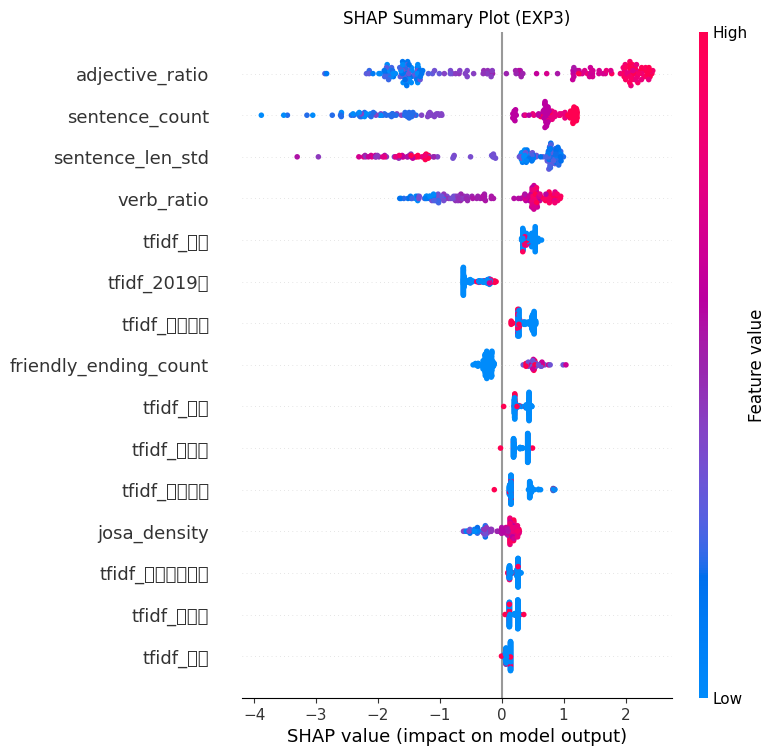

In [5]:
# FP/FN 분리
false_positive = test_df[(test_df["true_label"] == 0) & (test_df["pred_label"] == 1)].sort_values("ai_probability", ascending=False)
false_negative = test_df[(test_df["true_label"] == 1) & (test_df["pred_label"] == 0)].sort_values("ai_probability", ascending=True)

print(f"\n[False Positive 상위 사례] - 인간인데 AI로 판단된 광고성/기계적 글")
display(false_positive.head(3))

print(f"\n[False Negative 상위 사례] - AI인데 인간으로 판단된 고도의 위장 글")
display(false_negative.head(3))

import shap
print("\n[START] SHAP 분석 진행")
explainer = shap.TreeExplainer(model)
X_test_sample = X_test_final[:min(200, X_test_final.shape[0])].toarray()
shap_values = explainer.shap_values(X_test_sample)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, max_display=15, show=False)
plt.title(f"SHAP Summary Plot ({EXPERIMENT_NAME.upper()})")
plt.savefig(os.path.join(result_dir, "shap_summary.png"), bbox_inches='tight')
plt.show()

mean_abs_shap = np.abs(shap_values).mean(axis=0)
df_shap_imp = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap}).sort_values("mean_abs_shap", ascending=False)
df_shap_imp.to_csv(os.path.join(target_dir, f"{EXPERIMENT_NAME}_shap_feature_importance.csv"), index=False, encoding="utf-8-sig")

# 모든 CSV 저장
test_df.to_csv(os.path.join(result_dir, "test_prediction_results.csv"), index=False, encoding="utf-8-sig")
false_positive.to_csv(os.path.join(result_dir, "false_positive_cases.csv"), index=False, encoding="utf-8-sig")
false_negative.to_csv(os.path.join(result_dir, "false_negative_cases.csv"), index=False, encoding="utf-8-sig")

# 실험 요약 저장
summary_file = os.path.join(target_dir, "experiment_summary.csv")
interpretation = "AI 위장술 진화 자체 분석" if EXPERIMENT_NAME=="ai_vs_ai" else ("GPT형 AI 탐지" if EXPERIMENT_NAME=="exp1" else ("인간형 AI 탐지" if EXPERIMENT_NAME=="exp2" else "혼합 AI 탐지"))
summary_data = {
    "experiment": EXPERIMENT_NAME,
    "feature_mode": FEATURE_MODE,
    "accuracy": round(test_acc, 4),
    "f1": round(test_f1, 4),
    "cv_f1_mean": round(cv_mean, 4),
    "fp_count": len(false_positive),
    "fn_count": len(false_negative),
    "top_feature": df_shap_imp.iloc[0]["feature"],
    "main_interpretation": interpretation
}
summary_df = pd.DataFrame([summary_data])

if os.path.exists(summary_file):
    existing = pd.read_csv(summary_file, encoding="utf-8-sig")
    existing = existing[(existing["experiment"] != EXPERIMENT_NAME) | (existing["feature_mode"] != FEATURE_MODE)]
    summary_df = pd.concat([existing, summary_df], ignore_index=True)
summary_df.to_csv(summary_file, index=False, encoding="utf-8-sig")

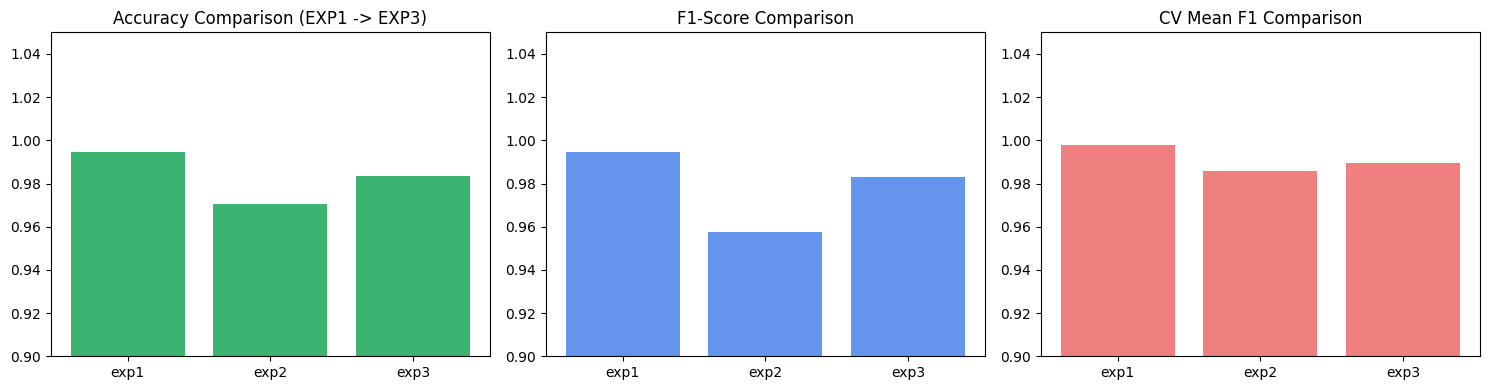

[SUCCESS] shap_transition_summary.csv 생성 완료 (EXP1 -> EXP3 탐지 패턴 진화 분석)


In [6]:
# ==========================================================================
# [최종 발표용 시각화 & SHAP 변화 비교] 자동 생성
# ==========================================================================
if os.path.exists(summary_file):
    summary_all = pd.read_csv(summary_file, encoding="utf-8-sig")
    df_exp = summary_all[(summary_all["feature_mode"] == "combined") & (summary_all["experiment"].isin(["exp1", "exp2", "exp3"]))].sort_values("experiment")
    
    if len(df_exp) >= 2:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # Accuracy 비교
        axes[0].bar(df_exp["experiment"], df_exp["accuracy"], color='mediumseagreen')
        axes[0].set_title("Accuracy Comparison (EXP1 -> EXP3)")
        axes[0].set_ylim(0.9, 1.05)
        
        # F1 비교
        axes[1].bar(df_exp["experiment"], df_exp["f1"], color='cornflowerblue')
        axes[1].set_title("F1-Score Comparison")
        axes[1].set_ylim(0.9, 1.05)
        
        # CV Mean 비교
        axes[2].bar(df_exp["experiment"], df_exp["cv_f1_mean"], color='lightcoral')
        axes[2].set_title("CV Mean F1 Comparison")
        axes[2].set_ylim(0.9, 1.05)
        
        plt.tight_layout()
        plt.savefig(os.path.join(target_dir, "exp_accuracy_f1_comparison.png"), bbox_inches='tight')
        plt.show()

# SHAP 중요도 변화량 계산 (EXP1 vs EXP3)
exp1_shap_file = os.path.join(target_dir, "exp1_shap_feature_importance.csv")
exp3_shap_file = os.path.join(target_dir, "exp3_shap_feature_importance.csv")

if os.path.exists(exp1_shap_file) and os.path.exists(exp3_shap_file):
    df_s1 = pd.read_csv(exp1_shap_file).rename(columns={"mean_abs_shap": "exp1_importance"})
    df_s3 = pd.read_csv(exp3_shap_file).rename(columns={"mean_abs_shap": "exp3_importance"})
    
    df_shap_merged = pd.merge(df_s1, df_s3, on="feature", how="inner")
    df_shap_merged["delta"] = df_shap_merged["exp3_importance"] - df_shap_merged["exp1_importance"]
    
    def get_interpretation(row):
        f = row["feature"]
        d = row["delta"]
        if "friendly_ending" in f and d < 0: return "GPT형 종결어미 특징 약화"
        if "sentence_len_std" in f and d > 0: return "구조적 문체 다양성 중요도 증가"
        if "adjective" in f and d < 0: return "감성/형용사 과다사용 감소"
        return "일반적 변동"
        
    df_shap_merged["interpretation"] = df_shap_merged.apply(get_interpretation, axis=1)
    df_shap_merged.sort_values(by="delta", key=abs, ascending=False).to_csv(os.path.join(target_dir, "shap_transition_summary.csv"), index=False, encoding="utf-8-sig")
    print("[SUCCESS] shap_transition_summary.csv 생성 완료 (EXP1 -> EXP3 탐지 패턴 진화 분석)")

# 발표용 최종 Summary Table
if os.path.exists(summary_file):
    final_df = summary_all.copy()
    final_df["Difficulty Level"] = final_df["accuracy"].apply(lambda x: "높음(어려움)" if x < 0.99 else "낮음(쉬움)")
    final_df.to_csv(os.path.join(target_dir, "final_presentation_summary.csv"), index=False, encoding="utf-8-sig")

## 7. 연구적 한계점 (Limitations)
본 연구는 유의미한 결론을 도출하였으나, 다음과 같은 한계가 존재합니다.
* **데이터 길이 통제의 한계:** `char_count` 등 직접적 피처는 제거했으나, 수집된 원본 데이터의 Human/AI 길이 분포 차이가 존재하여 `sentence_count`에 미세한 영향을 줄 수 있습니다.
* **AI_v2의 모사 한계:** 건조체를 강제했음에도 완벽한 인간의 고맥락(Contextual) 작성법을 100% 모사하지는 못했습니다.
* **데이터 규모:** 1,200건의 데이터는 블로그 생태계 전체를 대변하기에는 상대적으로 제한적입니다.

## 8. 향후 연구 방향 (Future Work)
* **최신 LLM 모델 데이터 추가:** GPT-4 Turbo, Claude 3 등 인간을 더 정교하게 속이는 LLM 텍스트로 확장 분석.
* **오타 및 불완전성 모델링:** 고의적인 오타, 띄어쓰기 오류 등을 추가한 '초정밀 인간형 위장 AI' 탐지 연구.
* **멀티모달 확장:** 텍스트뿐만 아니라 썸네일 이미지, 태그 분포를 함께 고려한 탐지 시스템 고도화.

## [핵심 결론 슬라이드]

1. **초기 GPT형 AI는 매우 쉽게 탐지되었다.** (EXP1)
2. **하지만 인간형 AI_v2를 포함하자 탐지 난이도가 뚜렷하게 증가(미탐률 상승)하였다.** (EXP3)
3. **특히 문체 패턴의 진화가 나타났다:** 
   - AI의 템플릿화된 종결어미(`friendly_ending_count`) 의존도는 **감소**하였고,
   - 문장의 길이 분산(`sentence_len_std`)과 같은 구조적 문체 피처의 중요도는 **증가**하였다.
4. **결론:** 이는 AI가 텍스트 생성을 넘어 인간의 '문체 호흡'까지 점진적으로 모방하고 있음을 증명한다.
5. **향후 방향:** 미래의 AI 어뷰징 탐지는 단순 특정 키워드나 말투 기반이 아니라, 문서 전체의 **'구조적/통계적 리듬'**을 복합적으로 분석하는 방향으로 나아가야 한다.